# 02 — Feature Engineering
**Input:** `data/processed/listings_clean.csv` (21,351 rows)  
**Output:** `data/processed/features.csv` — model-ready feature matrix + target

In [1]:
import warnings
warnings.filterwarnings('ignore')

import ast
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

CLEAN  = '../data/processed/listings_clean.csv'
OUTPUT = '../data/processed/features.csv'

df = pd.read_csv(CLEAN)
print(f'Loaded: {df.shape}')
df.head(3)

Loaded: (21263, 27)


,id,room_type,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,accommodates,bedrooms,beds,...,review_scores_rating,review_scores_cleanliness,review_scores_location,review_scores_value,host_is_superhost,host_listings_count,calculated_host_listings_count,reviews_per_month,bathrooms,is_shared_bath
0,2539,Private room,Kensington,Brooklyn,40.645937,-73.972164,Private room in condo,2,1.0,2.0,...,4.8,4.90,4.78,4.78,0.0,5.0,5,0.08,1.0,1
1,6848,Entire home/apt,Williamsburg,Brooklyn,40.709350,-73.953420,Entire rental unit,3,2.0,1.0,...,4.6,4.85,4.69,4.59,1.0,1.0,1,0.95,1.0,0
2,6872,Private room,East Harlem,Manhattan,40.801070,-73.942550,Private room in condo,1,1.0,1.0,...,5.0,5.00,5.00,5.00,0.0,2.0,2,0.04,1.0,1


## 1. Target Variable — Log Transform

EDA showed price is heavily right-skewed. `log1p(price)` makes it approximately normal, which helps every model we'll train. We keep the raw price too for interpretability.

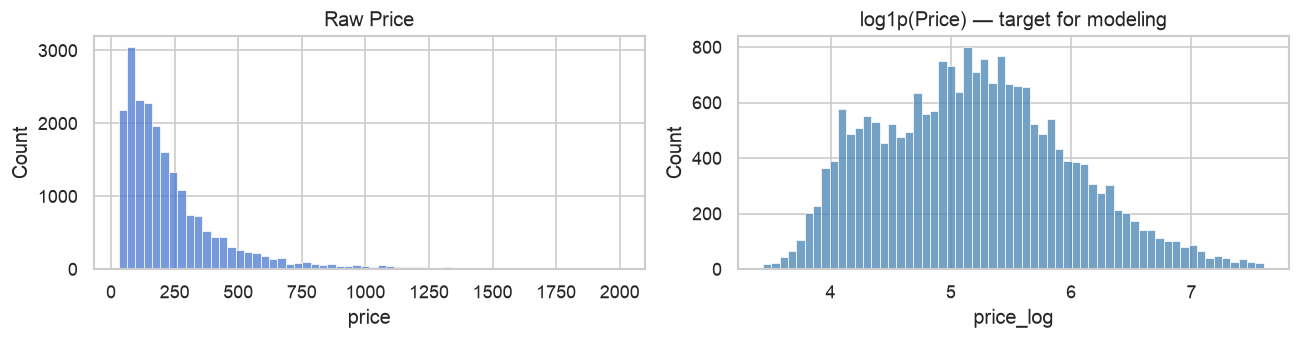

Skewness — raw: 2.82  |  log: 0.31


In [2]:
df['price_log'] = np.log1p(df['price'])

fig, axes = plt.subplots(1, 2, figsize=(11, 3))
sns.histplot(df['price'], bins=60, ax=axes[0])
axes[0].set_title('Raw Price')
sns.histplot(df['price_log'], bins=60, ax=axes[1], color='steelblue')
axes[1].set_title('log1p(Price) — target for modeling')
plt.tight_layout()
plt.savefig('../reports/figures/02_target_transform.png', bbox_inches='tight')
plt.show()

print(f"Skewness — raw: {df['price'].skew():.2f}  |  log: {df['price_log'].skew():.2f}")

## 2. Room Type & Property Type Encoding

`room_type` has 4 clean categories — simple one-hot encode.  
`property_type` has 30+ categories with a long tail — we collapse rare ones into `Other`.

In [3]:
print('room_type counts:')
print(df['room_type'].value_counts())
print()
print('property_type counts (top 15):')
print(df['property_type'].value_counts().head(15))

room_type counts:
room_type
Entire home/apt    11397
Private room        9228
Hotel room           457
Shared room          181
Name: count, dtype: int64

property_type counts (top 15):
property_type
Entire rental unit             8561
Private room in rental unit    4680
Private room in home           2118
Room in hotel                  1309
Entire home                    1020
Entire condo                    645
Private room in townhouse       627
Entire townhouse                318
Private room in condo           291
Entire loft                     245
Entire guest suite              233
Room in boutique hotel          187
Entire serviced apartment       178
Shared room in rental unit      134
Private room in guest suite     118
Name: count, dtype: int64


In [4]:
# Collapse property_type: keep top 10, everything else → 'Other'
top_property_types = df['property_type'].value_counts().head(10).index
df['property_type_grouped'] = df['property_type'].where(
    df['property_type'].isin(top_property_types), other='Other'
)

print('property_type_grouped counts:')
print(df['property_type_grouped'].value_counts())

property_type_grouped counts:
property_type_grouped
Entire rental unit             8561
Private room in rental unit    4680
Private room in home           2118
Other                          1449
Room in hotel                  1309
Entire home                    1020
Entire condo                    645
Private room in townhouse       627
Entire townhouse                318
Private room in condo           291
Entire loft                     245
Name: count, dtype: int64


In [5]:
# One-hot encode both
room_dummies = pd.get_dummies(df['room_type'], prefix='room', drop_first=True)
prop_dummies = pd.get_dummies(df['property_type_grouped'], prefix='prop', drop_first=True)

print('Room type dummies:', room_dummies.columns.tolist())
print('Property type dummies:', prop_dummies.columns.tolist())

Room type dummies: ['room_Hotel room', 'room_Private room', 'room_Shared room']
Property type dummies: ['prop_Entire home', 'prop_Entire loft', 'prop_Entire rental unit', 'prop_Entire townhouse', 'prop_Other', 'prop_Private room in condo', 'prop_Private room in home', 'prop_Private room in rental unit', 'prop_Private room in townhouse', 'prop_Room in hotel']


## 3. Neighbourhood — Pass Through for Target Encoding

222 unique neighbourhoods — one-hot encoding would add 221 sparse columns and risk overfitting. The standard fix is **target encoding**: replace each neighbourhood with the mean `log(price)` of listings in that neighbourhood.

**Important:** target encoding must be fit on the *training* split only, then applied to test — otherwise test-set prices leak into the encoding a test row receives. Since this notebook doesn't do the train/test split (that happens in notebook 03), we only pass `neighbourhood_cleansed` through here as a raw category. The actual encoding happens in notebook 03, after the split.

In [6]:
# Just verify the column is clean and ready to pass through — no encoding computed here
print(f"Unique neighbourhoods: {df['neighbourhood_cleansed'].nunique()}")
print(f"Nulls: {df['neighbourhood_cleansed'].isna().sum()}")
print()
print("Listings per neighbourhood (top 10):")
print(df['neighbourhood_cleansed'].value_counts().head(10))

Unique neighbourhoods: 222
Nulls: 0

Listings per neighbourhood (top 10):
neighbourhood_cleansed
Bedford-Stuyvesant    1498
Midtown               1332
Hell's Kitchen        1064
Harlem                1058
Upper East Side        857
Upper West Side        814
Williamsburg           801
Bushwick               655
Crown Heights          624
Chelsea                481
Name: count, dtype: int64


## 4. Amenity Feature Engineering

The `amenities` column is a JSON-like list string. We:
1. Parse it into a Python set per listing
2. Create binary flags for high-signal amenities (identified from EDA frequency + domain logic)
3. Add total amenity count as a richness signal

In [7]:
def parse_amenities(s):
    try:
        items = ast.literal_eval(s)
        return {re.sub(r'[^a-z0-9 ]', '', i.lower().strip()) for i in items}
    except Exception:
        return set()

parsed = df['amenities'].apply(parse_amenities)
print(f'Sample parsed: {list(parsed.iloc[0])[:6]} ...')

Sample parsed: ['conditioner', 'freezer', 'fast wifi  330 mbps', 'bed linens', 'kitchen', 'dishes and silverware'] ...


For binary flags, we choose 18 flags that covers the property information customers usually interested in knowing, such as wifi, air conditioning, gym etc.

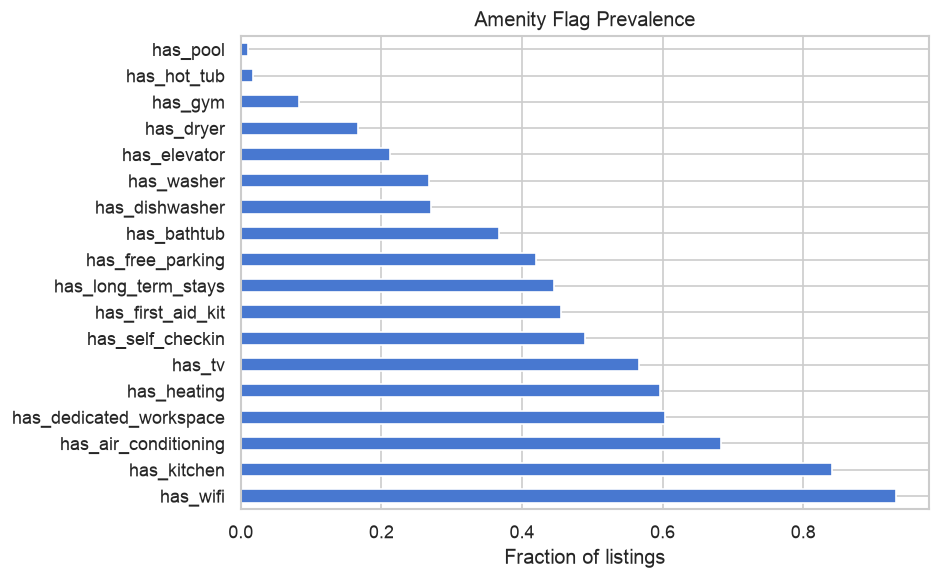

In [8]:
# Amenities chosen for binary flags:
# - Common enough to have statistical power (>10% of listings)
# - Plausibly price-differentiating (not just baseline hygiene like smoke alarm)
AMENITY_FLAGS = {
    'has_wifi':             'wifi',
    'has_kitchen':          'kitchen',
    'has_air_conditioning': 'air conditioning',
    'has_heating':          'heating',
    'has_tv':               'tv',
    'has_washer':           'washer',
    'has_dryer':            'dryer',
    'has_dishwasher':       'dishwasher',
    'has_dedicated_workspace': 'dedicated workspace',
    'has_self_checkin':     'self checkin',
    'has_elevator':         'elevator',
    'has_pool':             'pool',
    'has_hot_tub':          'hot tub',
    'has_gym':              'gym',
    'has_free_parking':     'free street parking',
    'has_bathtub':          'bathtub',
    'has_long_term_stays':  'long term stays allowed',
    'has_first_aid_kit':    'first aid kit',
}

for col, keyword in AMENITY_FLAGS.items():
    df[col] = parsed.apply(lambda s: int(keyword in s))

df['amenity_count'] = parsed.apply(len)

# Prevalence of each flag
flag_cols = list(AMENITY_FLAGS.keys())
prevalence = df[flag_cols].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
prevalence.plot(kind='barh', ax=ax)
ax.set_xlabel('Fraction of listings')
ax.set_title('Amenity Flag Prevalence')
plt.tight_layout()
plt.savefig('../reports/figures/02_amenity_prevalence.png', bbox_inches='tight')
plt.show()

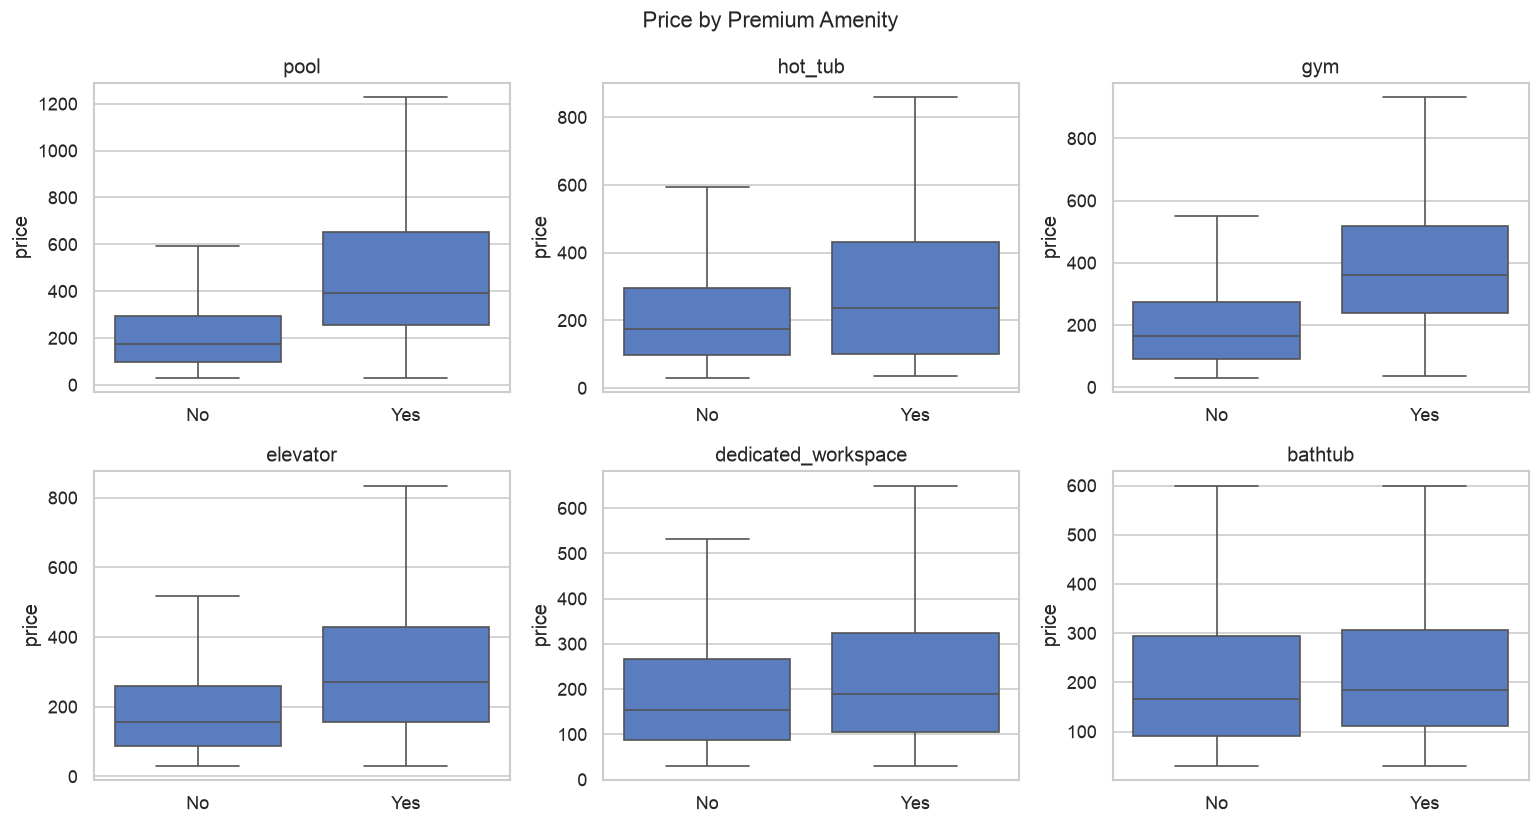

In [9]:
# Do premium amenities actually command higher prices?
premium = ['has_pool', 'has_hot_tub', 'has_gym', 'has_elevator', 'has_dedicated_workspace', 'has_bathtub']

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, col in zip(axes.flat, premium):
    sns.boxplot(data=df, x=col, y='price', showfliers=False, ax=ax)
    ax.set_xticklabels(['No', 'Yes'])
    ax.set_title(col.replace('has_', ''))
    ax.set_xlabel('')
plt.suptitle('Price by Premium Amenity', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/figures/02_amenity_price_impact.png', bbox_inches='tight')
plt.show()

## 5. Derived Features

In [10]:
# Distance to Times Square (NYC center proxy)
NYC_CENTER = (40.7580, -73.9855)

lat_r = np.radians(df['latitude'])
lon_r = np.radians(df['longitude'])
clat  = np.radians(NYC_CENTER[0])
clon  = np.radians(NYC_CENTER[1])
dlat  = lat_r - clat
dlon  = lon_r - clon
a = np.sin(dlat / 2)**2 + np.cos(lat_r) * np.cos(clat) * np.sin(dlon / 2)**2
df['distance_to_center_km'] = 6371 * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

print(df['distance_to_center_km'].describe().round(2))

count    21263.00
mean         7.87
std          5.64
min          0.01
25%          3.35
50%          7.21
75%         10.98
max         35.92
Name: distance_to_center_km, dtype: float64


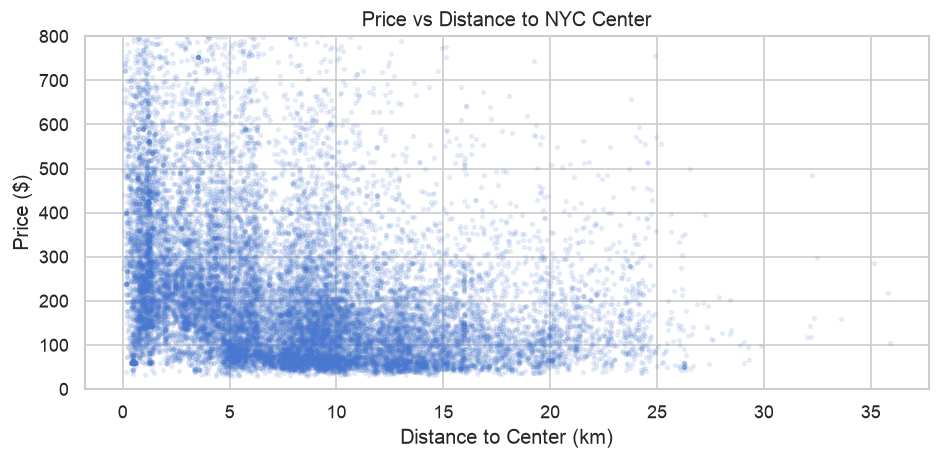

Correlation with price: -0.300


In [11]:
# Does closer to center = higher price?
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(df['distance_to_center_km'], df['price'], alpha=0.1, s=5)
ax.set_xlabel('Distance to Center (km)')
ax.set_ylabel('Price ($)')
ax.set_title('Price vs Distance to NYC Center')
ax.set_ylim(0, 800)
plt.tight_layout()
plt.savefig('../reports/figures/02_distance_vs_price.png', bbox_inches='tight')
plt.show()

print(f"Correlation with price: {df[['distance_to_center_km','price']].corr().iloc[0,1]:.3f}")

In [12]:
# Availability ratio: what fraction of the year is the listing available?
# High availability = host is trying to rent it; low = it books up fast or isn't actively listed
df['availability_ratio'] = df['availability_365'] / 365

# Review velocity: reviews per listing (proxy for booking frequency relative to host portfolio)
df['review_velocity'] = df['number_of_reviews'] / df['host_listings_count'].clip(lower=1)

# Is this a professional/multi-listing host?
df['is_multi_listing_host'] = (df['calculated_host_listings_count'] > 1).astype(int)

print('New derived features:')
print(df[['availability_ratio', 'review_velocity', 'is_multi_listing_host']].describe().round(3))

New derived features:
       availability_ratio  review_velocity  is_multi_listing_host
count           21263.000        21263.000              21263.000
mean                0.672           23.139                  0.637
std                 0.288           64.532                  0.481
min                 0.000            0.000                  0.000
25%                 0.452            0.000                  0.000
50%                 0.745            1.000                  1.000
75%                 0.918           17.000                  1.000
max                 1.000         4502.000                  1.000


## 6. Clean Up Remaining Numeric Features

In [13]:
# Clip minimum_nights — extreme values (365+) are edge cases, not useful signal
df['minimum_nights_clipped'] = df['minimum_nights'].clip(upper=30)

# host_is_superhost was mapped in EDA; ensure it's int
df['host_is_superhost'] = df['host_is_superhost'].fillna(0).astype(int)

print('minimum_nights clipped distribution:')
print(df['minimum_nights_clipped'].value_counts().head(10))

minimum_nights clipped distribution:
minimum_nights_clipped
30.0    16315
1.0      3403
2.0       845
3.0       391
4.0       115
5.0       112
7.0        37
29.0       15
6.0        10
10.0        8
Name: count, dtype: int64


## 7. Assemble Final Feature Matrix

In [14]:
NUMERIC_COLS = [
    'accommodates', 'bedrooms', 'beds', 'bathrooms', 'is_shared_bath',
    'minimum_nights_clipped', 'availability_ratio',
    'number_of_reviews', 'reviews_per_month', 'review_velocity',
    'review_scores_rating', 'review_scores_cleanliness',
    'review_scores_location', 'review_scores_value',
    'host_is_superhost', 'host_listings_count', 'is_multi_listing_host',
    'distance_to_center_km',
    'amenity_count',
] + flag_cols

# neighbourhood_cleansed carried through RAW (not encoded) — target encoding
# happens in notebook 03, after the train/test split, to avoid leakage
X = pd.concat([df[NUMERIC_COLS], room_dummies, prop_dummies, df[['neighbourhood_cleansed']]], axis=1)
y = df['price_log']
y_raw = df['price']

print(f'Feature matrix shape: {X.shape}')
print(f'Features ({len(X.columns)}):')
print(X.columns.tolist())

Feature matrix shape: (21263, 51)
Features (51):
['accommodates', 'bedrooms', 'beds', 'bathrooms', 'is_shared_bath', 'minimum_nights_clipped', 'availability_ratio', 'number_of_reviews', 'reviews_per_month', 'review_velocity', 'review_scores_rating', 'review_scores_cleanliness', 'review_scores_location', 'review_scores_value', 'host_is_superhost', 'host_listings_count', 'is_multi_listing_host', 'distance_to_center_km', 'amenity_count', 'has_wifi', 'has_kitchen', 'has_air_conditioning', 'has_heating', 'has_tv', 'has_washer', 'has_dryer', 'has_dishwasher', 'has_dedicated_workspace', 'has_self_checkin', 'has_elevator', 'has_pool', 'has_hot_tub', 'has_gym', 'has_free_parking', 'has_bathtub', 'has_long_term_stays', 'has_first_aid_kit', 'room_Hotel room', 'room_Private room', 'room_Shared room', 'prop_Entire home', 'prop_Entire loft', 'prop_Entire rental unit', 'prop_Entire townhouse', 'prop_Other', 'prop_Private room in condo', 'prop_Private room in home', 'prop_Private room in rental unit',

In [15]:
# Sanity check: no nulls in feature matrix
null_counts = X.isnull().sum()
if null_counts.any():
    print('Nulls found:')
    print(null_counts[null_counts > 0])
else:
    print('No nulls in feature matrix — ready to model.')

X.describe().round(2)

Nulls found:
minimum_nights_clipped    1
dtype: int64


,accommodates,bedrooms,beds,bathrooms,is_shared_bath,minimum_nights_clipped,availability_ratio,number_of_reviews,reviews_per_month,review_velocity,...,has_dedicated_workspace,has_self_checkin,has_elevator,has_pool,has_hot_tub,has_gym,has_free_parking,has_bathtub,has_long_term_stays,has_first_aid_kit
count,21263.00,21263.00,21263.00,21263.00,21263.00,21262.00,21263.00,21263.00,21263.00,21263.00,...,21263.00,21263.00,21263.00,21263.00,21263.00,21263.00,21263.00,21263.00,21263.00,21263.00
mean,2.93,1.39,1.66,1.19,0.25,23.41,0.67,39.47,0.78,23.14,...,0.60,0.49,0.21,0.01,0.02,0.08,0.42,0.37,0.45,0.46
std,2.07,0.78,1.16,0.49,0.43,12.01,0.29,90.30,1.87,64.53,...,0.49,0.50,0.41,0.10,0.13,0.27,0.49,0.48,0.50,0.50
min,1.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,2.00,1.00,1.00,1.00,0.00,30.00,0.45,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,2.00,1.00,1.00,1.00,0.00,30.00,0.75,6.00,0.19,1.00,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,4.00,2.00,2.00,1.00,0.00,30.00,0.92,41.00,0.86,17.00,...,1.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00
max,16.00,12.00,18.00,10.50,1.00,30.00,1.00,4502.00,115.63,4502.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


## 8. Feature Correlation with Target

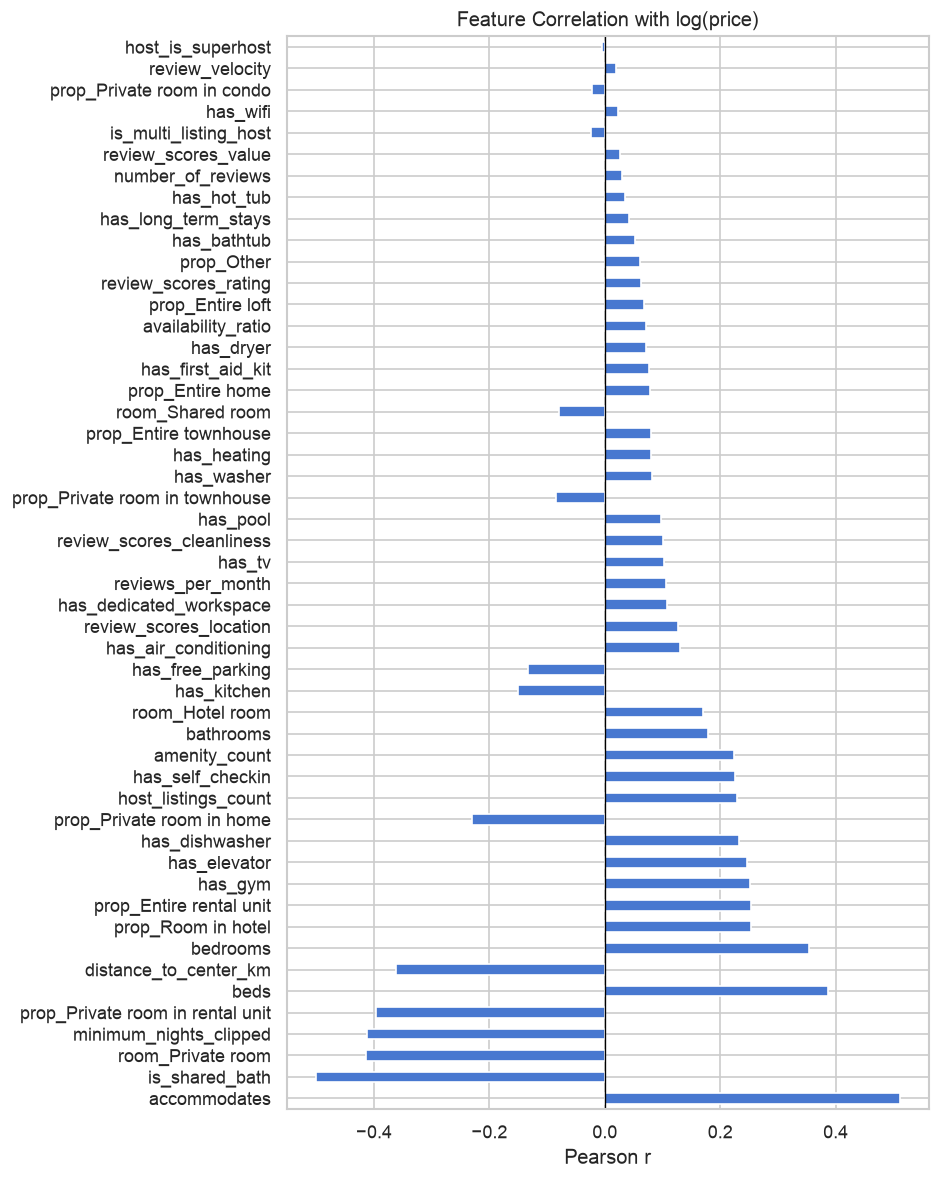

,corr_with_log_price
accommodates,0.510774
is_shared_bath,-0.500530
room_Private room,-0.413543
minimum_nights_clipped,-0.412616
prop_Private room in rental unit,-0.396634
beds,0.386502
distance_to_center_km,-0.361306
bedrooms,0.353592
prop_Room in hotel,0.253328
prop_Entire rental unit,0.253075


In [16]:
corr_with_target = X.drop(columns=['neighbourhood_cleansed']).corrwith(y).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 10))
corr_with_target.plot(kind='barh', ax=ax)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with log(price)')
ax.set_xlabel('Pearson r')
plt.tight_layout()
plt.savefig('../reports/figures/02_feature_correlations.png', bbox_inches='tight')
plt.show()

corr_with_target.to_frame('corr_with_log_price')

## 9. Save Feature Matrix

In [17]:
out = X.copy()
out['price_log'] = y.values
out['price']     = y_raw.values
out['id']        = df['id'].values

out.to_csv(OUTPUT, index=False)
print(f'Saved {out.shape[0]:,} rows × {out.shape[1]} cols → {OUTPUT}')

Saved 21,263 rows × 54 cols → ../data/processed/features.csv


## Feature Engineering Summary

| Feature group | Count | Notes |
|---|---|---|
| Raw numeric (size, reviews, host) | 17 | Clipped `minimum_nights` at 30 |
| Room type dummies | 3 | `Entire home/apt` is reference |
| Property type dummies | 10 | Rare types collapsed to `Other` |
| Neighbourhood (raw category) | 1 | Passed through raw — target-encoded in notebook 03 after the train/test split, to avoid leakage |
| Amenity binary flags | 18 | Chosen for prevalence + price signal |
| Amenity count | 1 | Total richness of listing |
| Distance to center | 1 | Haversine km from Times Square |
| Derived (ratio, velocity) | 3 | availability_ratio, review_velocity, is_multi_listing_host |
| **Total** | **~54** | |

**Note:** HuggingFace sentence embeddings (8 PCA components) will be added in notebook 03 for the final model only, since they require a separate encode step per train/test split.